In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [39]:
injections = pd.read_csv('injections.dat', delimiter='\t')
injections.head()

,simulation_id,longitude,latitude,inclination,distance,mass1,mass2,spin1z,spin2z
0,0,2.993575,0.315697,2.003086,1014.32410,8.840354,1.537325,0.572837,0.030052
1,1,3.398123,1.384311,1.068921,1093.00530,6.230306,1.718148,-0.811314,-0.029605
2,2,1.141506,1.188156,2.629991,2249.33870,36.130994,1.789815,-0.493388,0.035751
3,3,5.923145,1.053362,2.030131,333.73846,5.611615,1.384739,-0.268517,0.027102
4,4,0.676933,-0.927833,0.719283,1849.92140,8.004366,1.754270,0.737033,0.012693


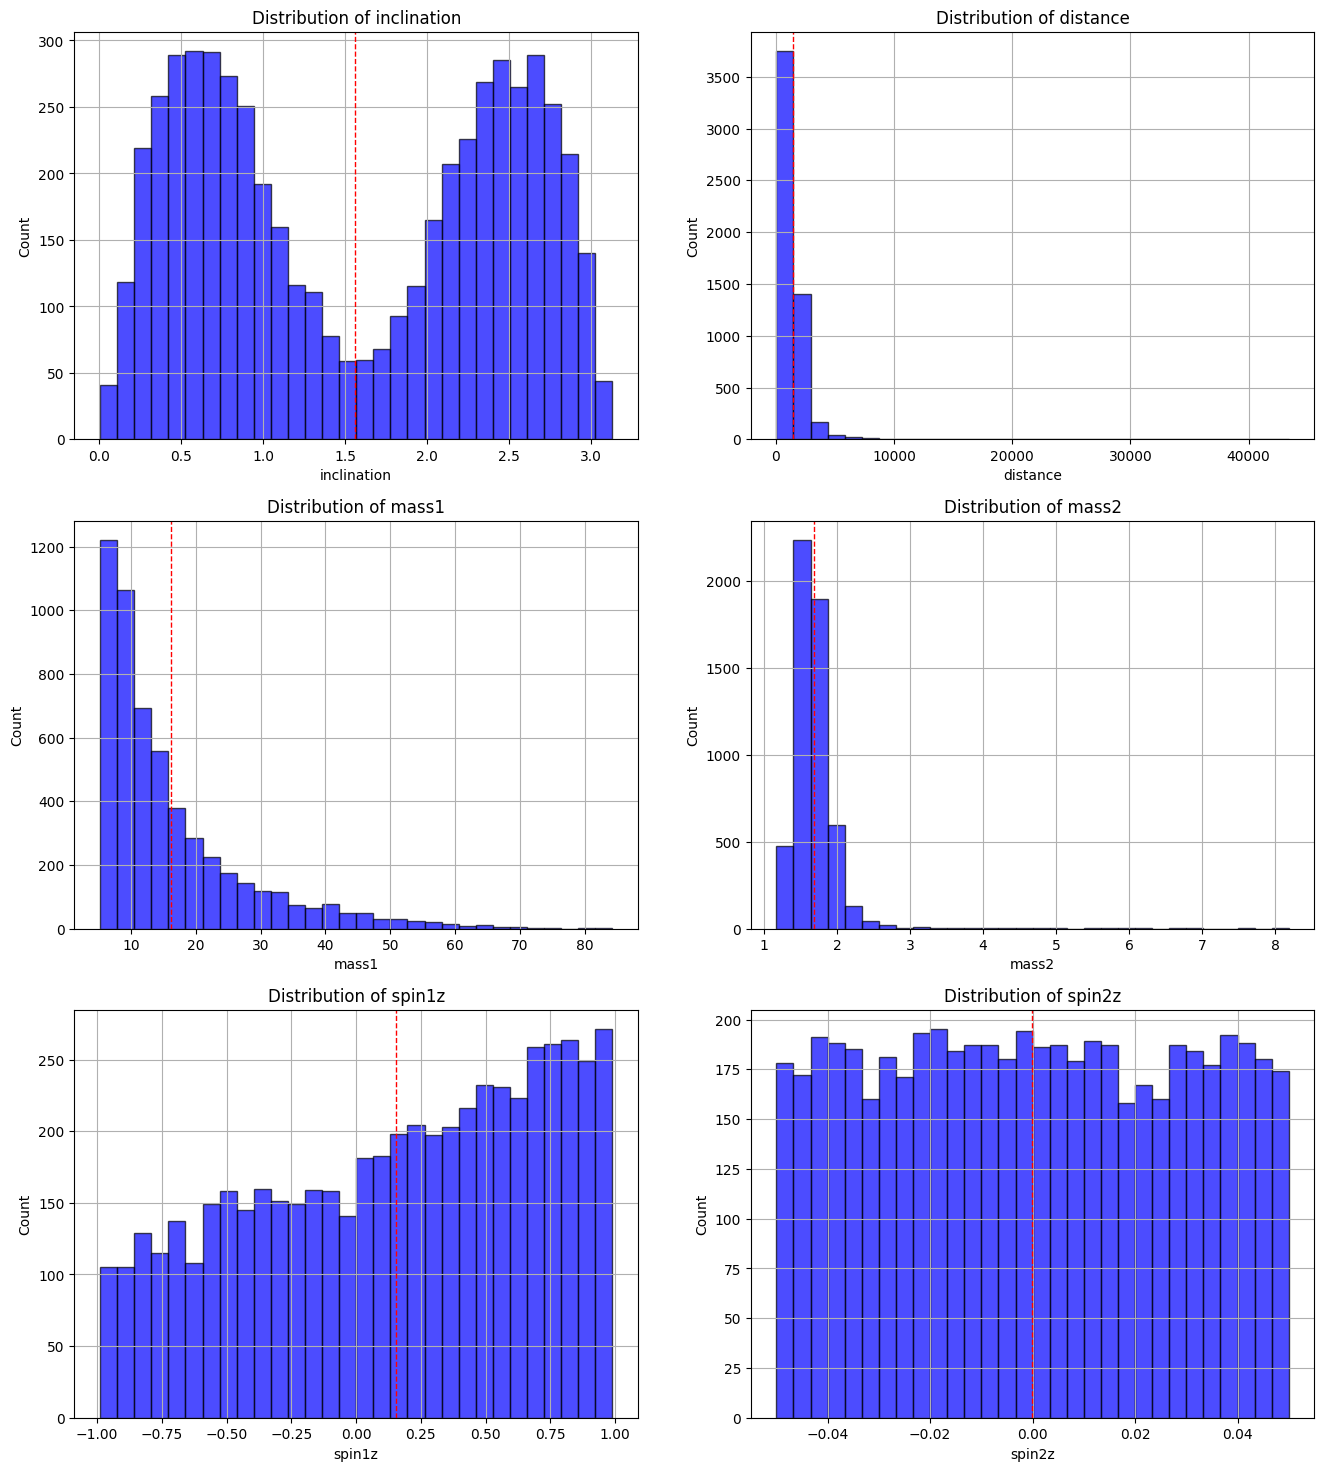

In [40]:
plt.figure(figsize=(16,18))
parameter_names = ['inclination', 'distance', 'mass1', 'mass2', 'spin1z', 'spin2z']

for i, param in enumerate(parameter_names):
    plt.subplot(3, 2, i+1)
    plt.hist(injections[param], bins=30, alpha=0.7, color='blue', edgecolor='black')
    mean = injections[param].mean()
    std = injections[param].std()
    plt.axvline(mean, color='red', linestyle='dashed', linewidth=1)
    # plt.axvline(mean + std, color='green', linestyle='dashed', linewidth=1)
    # plt.axvline(mean - std, color='green', linestyle='dashed', linewidth=1)
    plt.title(f'Distribution of {param}')
    plt.xlabel(param)
    plt.ylabel('Count')
    plt.grid()
plt.show()

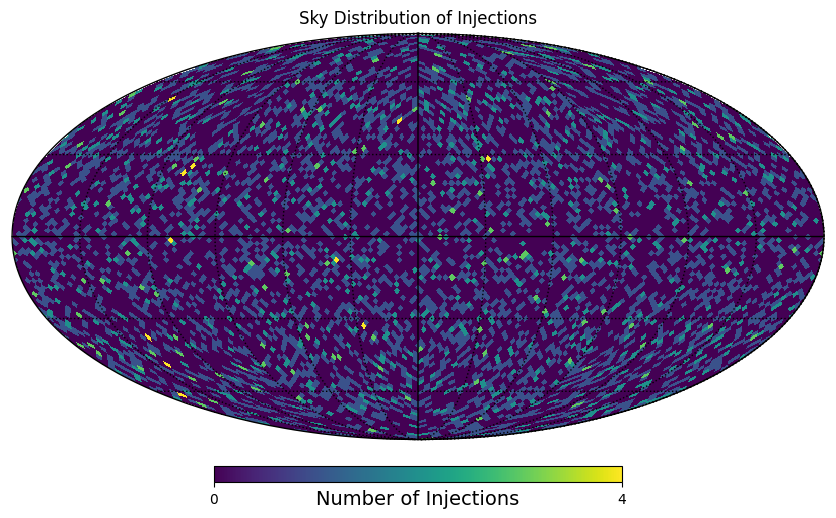

In [41]:
import healpy as hp
theta = injections['latitude'].values + np.pi/2
phi = injections['longitude'].values

nside = 32
npix = hp.nside2npix(nside)
sky_map = np.zeros(npix)
pixels = hp.ang2pix(nside, theta, phi)
for pix in pixels:
    sky_map[pix] += 1
hp.mollview(sky_map, title='Sky Distribution of Injections', unit='Number of Injections')
hp.graticule()

In [42]:
from astropy.cosmology import Planck18 as cosmo
from astropy.cosmology import z_at_value
import numpy as np

import astropy.units as u

def z_to_comoving_volume(z, cosmology=cosmo):
    """
    将红移 z（标量或数组）转换为共动体积（返回 astropy Quantity，单位 Mpc^3）。
    """
    return cosmology.comoving_volume(z)

def comoving_volume_to_z(V, cosmology=cosmo, z_max=20.0, ngrid=20000):
    """
    将共动体积 V 转回红移。
    - V 可以是带单位的 astropy Quantity（例如 1e9 * u.Mpc**3）或裸浮点（视为 Mpc^3）。
    - 对标量使用 astropy.cosmology.z_at_value 精确反演；对数组使用在 [0, z_max] 上的插值近似反演。
    - 返回标量或 numpy 数组（与输入形状一致）。
    """
    # 规范为 Quantity（单位 Mpc^3）
    if not hasattr(V, 'unit'):
        V = V * u.Mpc**3
    else:
        V = V.to(u.Mpc**3)

    # 标量情况：用 z_at_value
    if np.ndim(V.value) == 0:
        return z_at_value(cosmology.comoving_volume, V)

    # 数组情况：在 z 网格上计算共动体积并插值
    z_grid = np.linspace(0.0, z_max, ngrid)
    V_grid = cosmology.comoving_volume(z_grid).to(u.Mpc**3).value
    V_vals = np.asarray(V.value)
    z_vals = np.interp(V_vals, V_grid, z_grid, left=np.nan, right=np.nan)
    return z_vals

# 示例
z_example = np.array([0.10, 0.5, 1.0, 2.0])
V_example = z_to_comoving_volume(z_example)
print("z -> V (Mpc^3):", V_example)
print("V -> z (invert):", comoving_volume_to_z(V_example))

z -> V (Mpc^3): [3.39035239e+08 3.08884440e+10 1.64002856e+11 6.26509577e+11] Mpc3
V -> z (invert): [0.09999995 0.49999997 0.99999998 2.        ]


In [43]:
allsky = pd.read_csv('allsky.dat',delimiter='\t')
allsky.sort_values('coinc_event_id', inplace=True)
allsky.head()

,coinc_event_id,simulation_id,far,snr,searched_area,searched_prob,searched_prob_dist,searched_vol,searched_prob_vol,offset,...,log_bsn,area(20),area(50),area(90),dist(20),dist(50),dist(90),vol(20),vol(50),vol(90)
0,0,0,0.0,9.512454,3.130959,0.043541,0.196476,1.216825e+05,0.008125,1.639845,...,2.832098,20.560850,118.160504,2004.990985,257.860574,689.381319,1722.693543,6.056543e+06,4.340654e+07,1.090559e+09
1,1,1,0.0,8.227068,403.280597,0.244448,0.182415,9.046987e+07,0.182402,12.621143,...,0.402101,296.640870,1628.380769,10938.788049,263.339501,700.271163,1693.966425,1.052752e+08,7.061791e+08,6.543815e+09
2,2,2,0.0,8.474186,853.141990,0.683397,0.690754,5.275778e+08,0.636865,23.773294,...,3.006703,116.788996,414.823003,2992.640191,309.455985,823.190311,1997.274548,6.470257e+07,2.873313e+08,2.747292e+09
3,3,3,0.0,11.855322,11.389477,0.804772,0.032415,5.407083e+05,0.835697,1.884156,...,19.933731,1.296900,4.363683,17.495898,74.736977,199.047199,486.743464,3.583622e+04,1.429859e+05,8.056127e+05
4,4,4,0.0,8.203257,18.097269,0.031716,0.462401,1.320269e+07,0.044877,1.951029,...,-1.467300,230.891455,1265.662008,11677.321337,360.610296,956.335001,2294.971639,1.157630e+08,8.949482e+08,1.296023e+10


In [44]:
coincs = pd.read_csv('coincs.dat', delimiter='\t')
coincs.head()

,coinc_event_id,ifos,snr
0,0,"H1,K1,L1,V1",9.512454
1,1,"H1,K1,V1",8.227068
2,2,"H1,K1,L1,V1",8.474186
3,3,"H1,K1,V1",11.855322
4,4,"H1,K1,L1,V1",8.203257


绘制定位天区以及距离在injection以及skymap结果中的差别：部分低信噪比事件会导致距离定位偏差极大

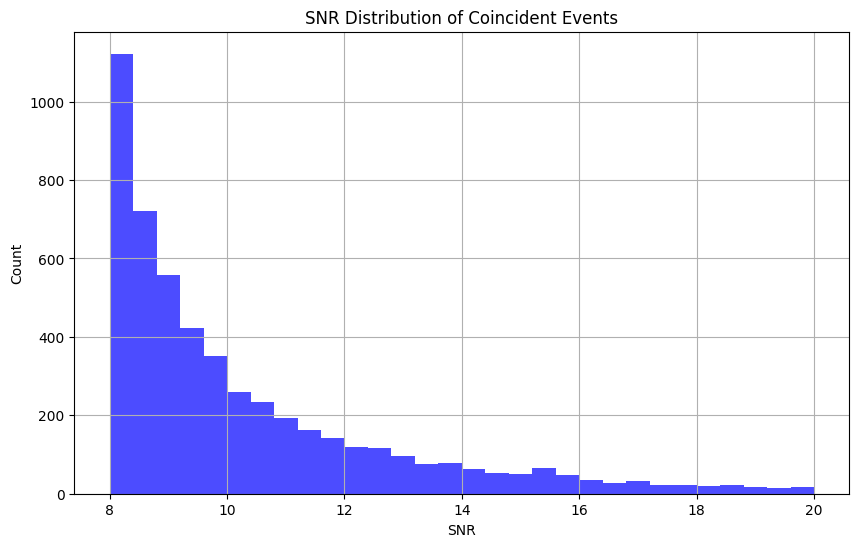

In [45]:
plt.figure(figsize=(10,6))
plt.hist(allsky['snr'].values, range=[8,20], bins=30, alpha=0.7, color='b')
plt.title('SNR Distribution of Coincident Events')
plt.xlabel('SNR')
plt.ylabel('Count')
plt.grid()
plt.show()

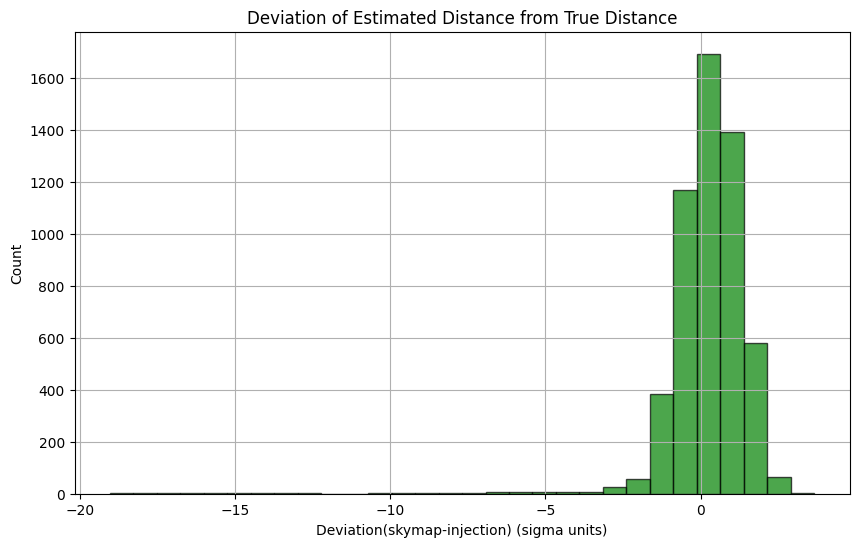

In [46]:
inj_dist = injections['distance'].values
allsky_dist = allsky['distmean'].values
allsky_diststd = allsky['diststd'].values
deviation = (allsky_dist - inj_dist) / allsky_diststd
plt.figure(figsize=(10,6))
plt.hist(deviation, bins=30, alpha=0.7, color='green', edgecolor='black')
plt.title('Deviation of Estimated Distance from True Distance')
plt.xlabel('Deviation(skymap-injection) (sigma units)')
plt.ylabel('Count')
plt.grid()

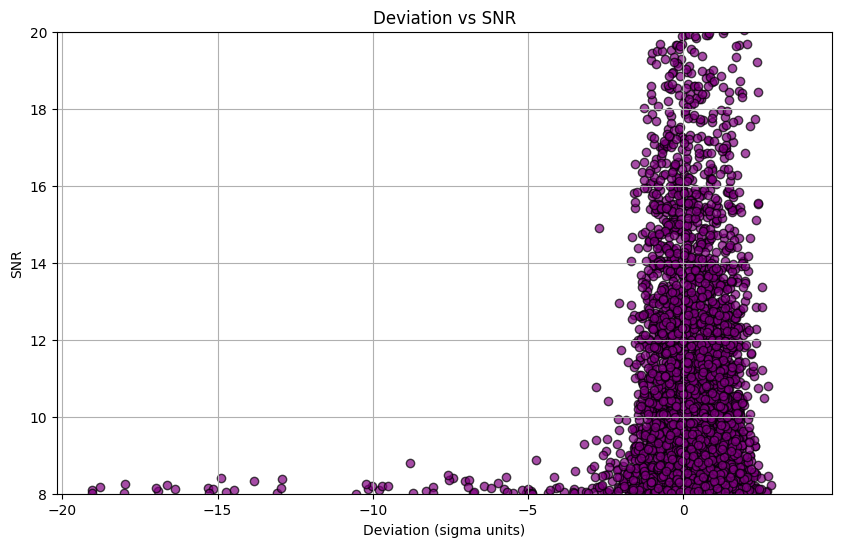

In [47]:
snr = allsky['snr'].values
plt.figure(figsize=(10,6))
plt.scatter(deviation, snr, alpha=0.7, color='purple', edgecolor='black')
plt.title('Deviation vs SNR')
plt.xlabel('Deviation (sigma units)')
plt.ylabel('SNR')
plt.ylim((8,20))
plt.grid()

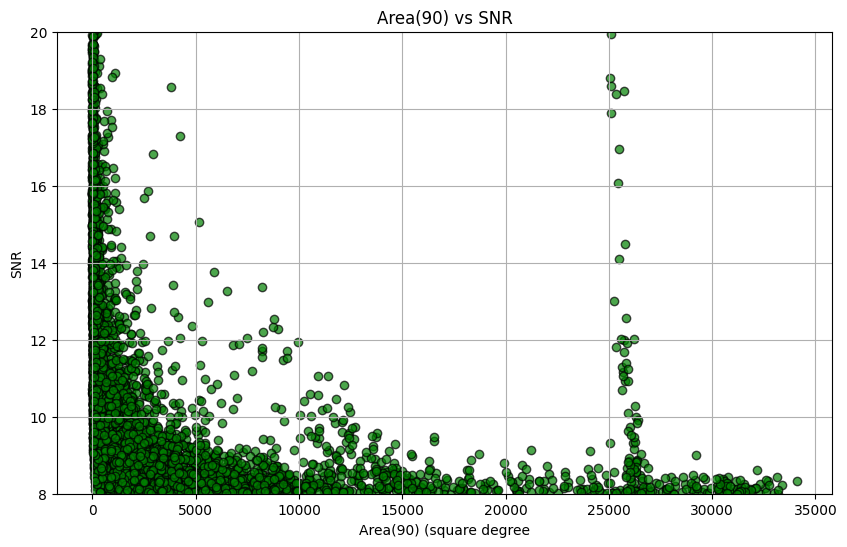

In [48]:
# plot area(90) vs snr
area90 = allsky['area(90)'].values
snr = allsky['snr'].values
plt.figure(figsize=(10,6))
plt.scatter(area90, snr, alpha=0.7, color='g', edgecolor='black')
plt.title('Area(90) vs SNR')
plt.xlabel('Area(90) (square degree')
plt.ylabel('SNR')
plt.ylim((8,20))
plt.grid()

#Remove events with distance > 4000Mpc or mass_ns > 2.0605 $M_{\odot}$, which is the upper limit mass of EOS.

(array([2.910e+02, 8.790e+02, 1.137e+03, 9.820e+02, 7.770e+02, 4.750e+02,
        2.950e+02, 1.920e+02, 1.130e+02, 7.400e+01, 4.700e+01, 3.800e+01,
        1.300e+01, 1.700e+01, 1.400e+01, 6.000e+00, 4.000e+00, 4.000e+00,
        2.000e+00, 4.000e+00, 5.000e+00, 1.000e+00, 0.000e+00, 0.000e+00,
        2.000e+00]),
 array([  50.141736  ,  368.22485456,  686.30797312, 1004.39109168,
        1322.47421024, 1640.5573288 , 1958.64044736, 2276.72356592,
        2594.80668448, 2912.88980304, 3230.9729216 , 3549.05604016,
        3867.13915872, 4185.22227728, 4503.30539584, 4821.3885144 ,
        5139.47163296, 5457.55475152, 5775.63787008, 6093.72098864,
        6411.8041072 , 6729.88722576, 7047.97034432, 7366.05346288,
        7684.13658144, 8002.2197    ]),
 <BarContainer object of 25 artists>)

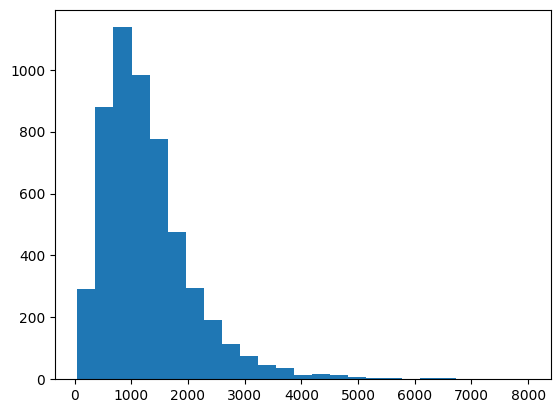

In [49]:
index = np.where(np.abs(deviation)<=3)[0]
plt.hist(injections['distance'][index],bins=25)

In [50]:
index = np.where(np.logical_and(injections['distance']<=4000, injections['mass2']<2.0605))[0]
print(f"Number of injections before cut: {len(injections)}")
print(f"Number of injections after cut: {len(index)}")
injections1 = injections.iloc[index]
coincs1 = coincs.iloc[index]
allsky1 = allsky.iloc[index]

Number of injections before cut: 5441
Number of injections after cut: 5131


In [51]:
injections1.reset_index(drop=True, inplace=True)
coincs1.reset_index(drop=True, inplace=True)
allsky1.reset_index(drop=True, inplace=True)
injections1.to_csv('injections_cleaned.csv', sep=',', index=False)
coincs1.to_csv('coincs_cleaned.csv', sep=',', index=False)  
allsky1.to_csv('allsky_cleaned.csv', sep=',', index=False)

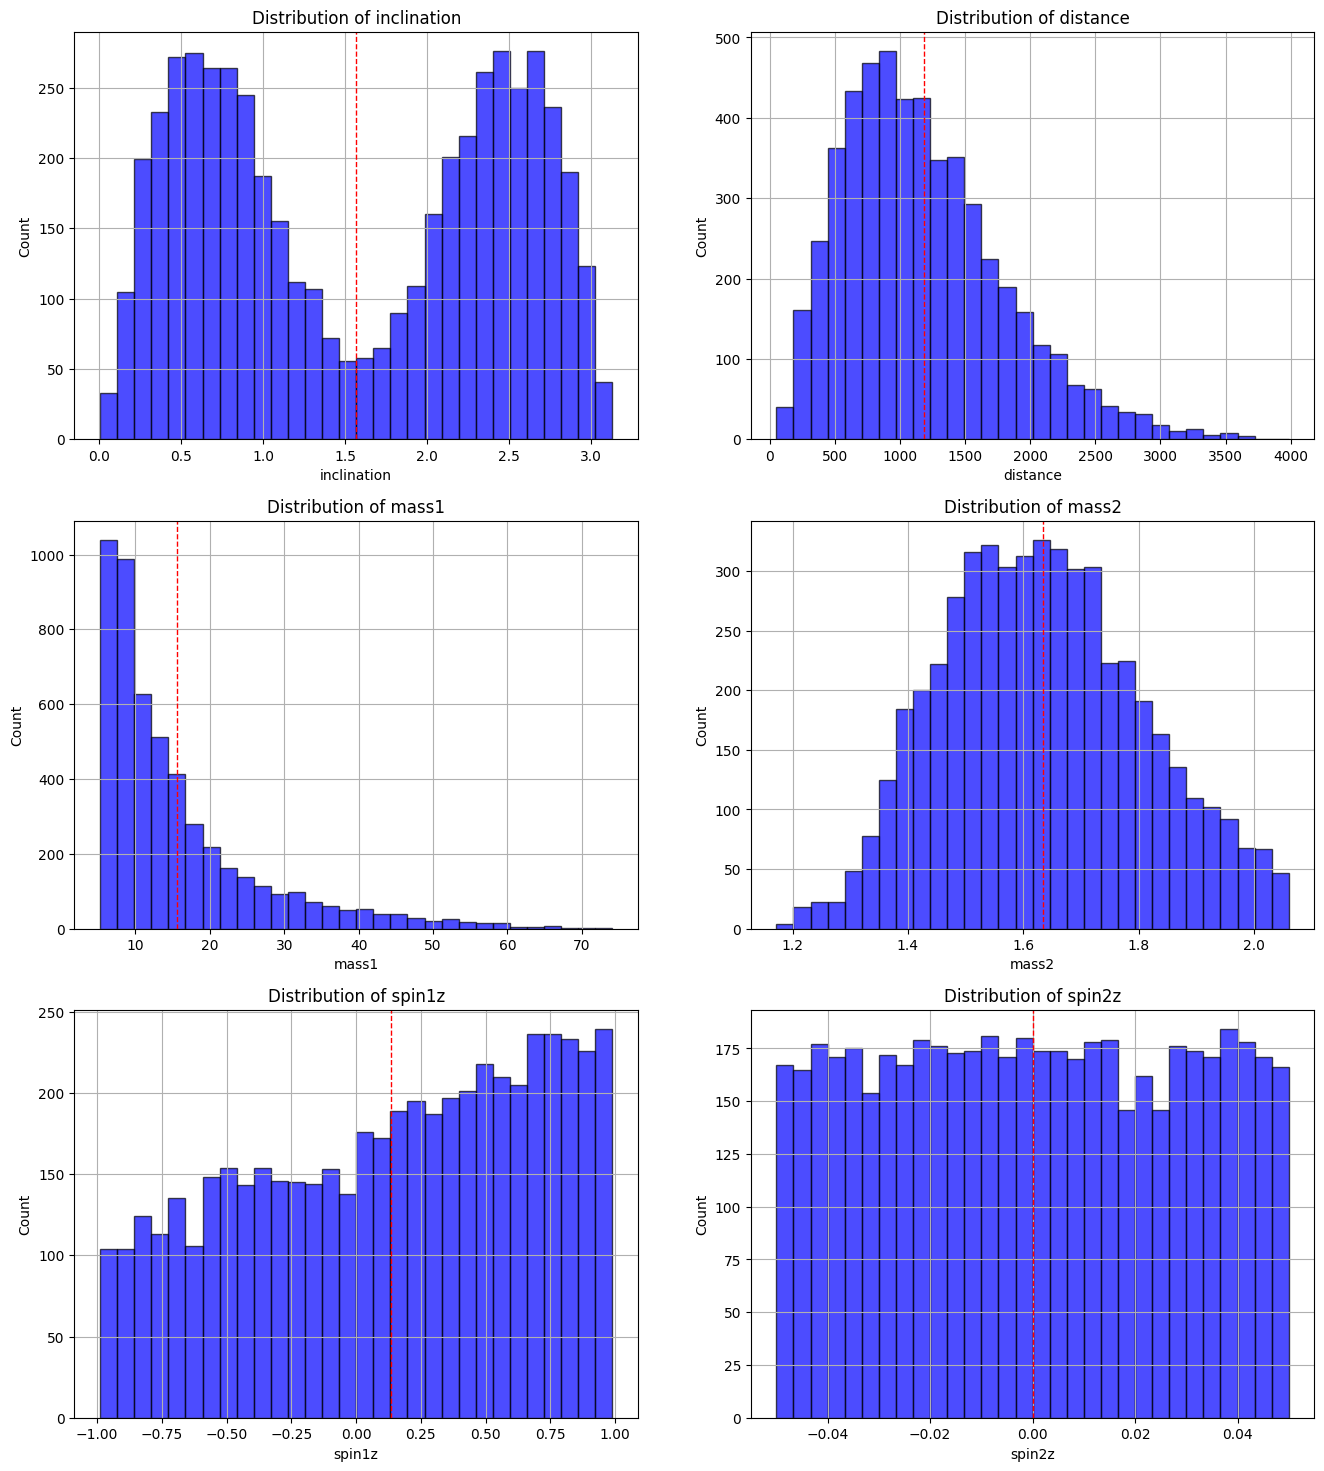

In [52]:
plt.figure(figsize=(16,18))
parameter_names = ['inclination', 'distance', 'mass1', 'mass2', 'spin1z', 'spin2z']

for i, param in enumerate(parameter_names):
    plt.subplot(3, 2, i+1)
    plt.hist(injections1[param], bins=30, alpha=0.7, color='blue', edgecolor='black')
    mean = injections1[param].mean()
    std = injections1[param].std()
    plt.axvline(mean, color='red', linestyle='dashed', linewidth=1)
    # plt.axvline(mean + std, color='green', linestyle='dashed', linewidth=1)
    # plt.axvline(mean - std, color='green', linestyle='dashed', linewidth=1)
    plt.title(f'Distribution of {param}')
    plt.xlabel(param)
    plt.ylabel('Count')
    plt.grid()
plt.show()

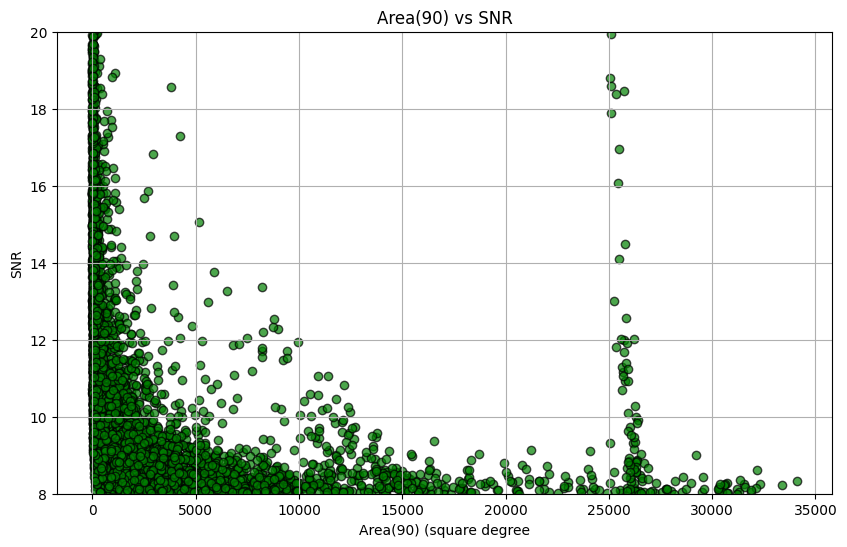

In [53]:
# plot area(90) vs snr
area901 = allsky1['area(90)'].values
snr1 = allsky1['snr'].values
plt.figure(figsize=(10,6))
plt.scatter(area901, snr1, alpha=0.7, color='g', edgecolor='black')
plt.title('Area(90) vs SNR')
plt.xlabel('Area(90) (square degree')
plt.ylabel('SNR')
plt.ylim((8,20))
plt.grid()

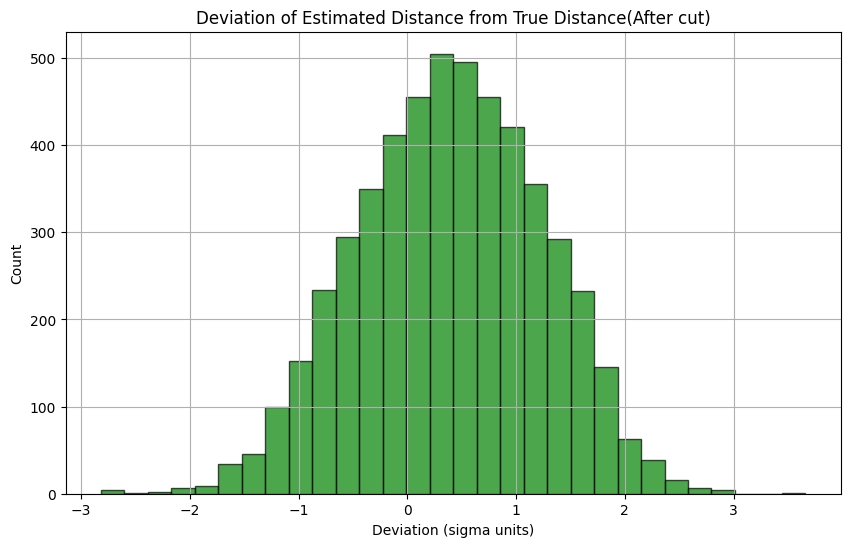

In [54]:
inj1_dist = injections1['distance'].values
allsky1_dist = allsky1['distmean'].values
allsky1_diststd = allsky1['diststd'].values
deviation1 = (allsky1_dist - inj1_dist) / allsky1_diststd
plt.figure(figsize=(10,6))
plt.hist(deviation1, bins=30, alpha=0.7, color='green', edgecolor='black')
plt.title('Deviation of Estimated Distance from True Distance(After cut)')
plt.xlabel('Deviation (sigma units)')
plt.ylabel('Count')
plt.grid()

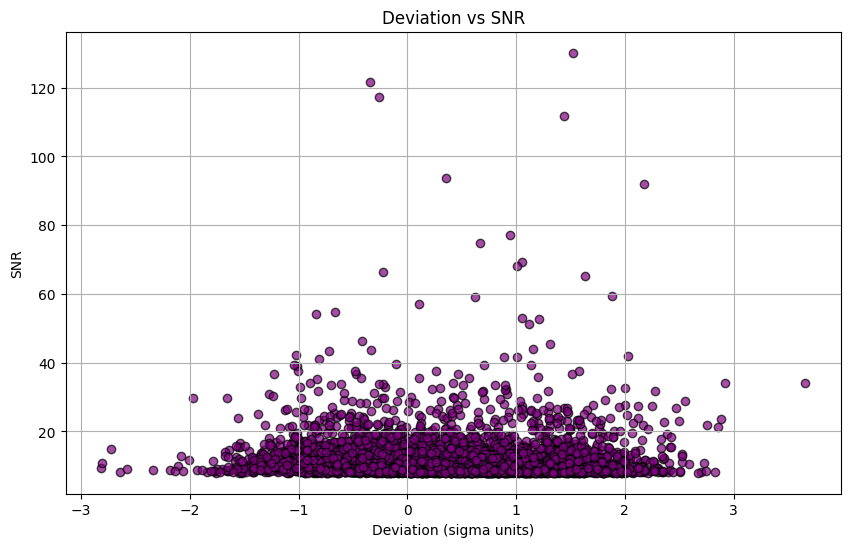

In [55]:
plt.figure(figsize=(10,6))
plt.scatter(deviation1, snr1, alpha=0.7, color='purple', edgecolor='black')
plt.title('Deviation vs SNR')
plt.xlabel('Deviation (sigma units)')
plt.ylabel('SNR')
# plt.ylim((8,20))
plt.grid()